In [2]:
# import libraries
import pandas as pd
import numpy as np


In [3]:
# define the raw 60 cl data
data_60cl = [
    # -------- Accurate filling --------
    (602.6, 9.2, 20.000, "normal"),
    (598.9, 6.6, 20.000, "normal"),
    (602.1, 6.8, 20.000, "normal"),
    (602.7, 7.2, 18.320, "normal"),
    (602.8, 9.1, 18.320, "normal"),
    (603.3, 6.3, 18.320, "normal"),
    (602.3, 6.2, 20.000, "normal"),
    (603.3, 10.1, 20.000, "normal"),
    (603.9, 6.8, 18.000, "normal"),
    (604.3, 6.2, 18.000, "normal"),
    (604.1, 6.7, 18.000, "normal"),
    (604.3, 6.6, 18.000, "normal"),
    (602.3, 6.4, 18.000, "normal"),
    (603.8, 10.18, 18.000, "normal"),
    (603.7, 17.2, 18.000, "normal"),
    (603.8, 9.1, 18.000, "normal"),
    (603.5, 6.2, 18.000, "normal"),
    (602.1, 7.8, 18.000, "normal"),
    (604.8, 8.1, 18.000, "normal"),
    (603.8, 9.8, 18.000, "normal"),
    (603.7, 7.9, 20.010, "normal"),
    (601.1, 6.8, 20.010, "normal"),
    (602.4, 6.2, 20.010, "normal"),
    (603.7, 19.1, 18.000, "normal"),
    (603.8, 18.3, 18.000, "normal"),
    (603.7, 16.4, 18.000, "normal"),
    (602.2, 12.8, 20.000, "normal"),
    (602.3, 19.1, 16.210, "normal"),
    (597.8, 18.9, 16.210, "normal"),
    (599.8, 21.3, 5.928, "normal"),
    (599.9, 5.2, 20.860, "normal"),
    (600.2, 5.8, 20.012, "normal"),
    (602.2, 6.2, 19.100, "normal"),

    # -------- Underfilling --------
    (540.3, 12.3, 17.420, "under"),
    (532.8, 11.2, 17.812, "under"),
    (591.1, 11.4, 15.200, "under"),
    (591.8, 11.2, 19.000, "under"),
    (509.1, 16.4, 8.290, "under"),
    (512.6, 19.2, 8.102, "under"),
    (508.4, 14.1, 12.190, "under"),
    (509.9, 11.2, 18.000, "under"),
    (522.3, 24.1, 6.219, "under"),
    (562.1, 19.2, 14.200, "under"),
    (488.8, 13.2, 17.360, "under"),
    (421.2, 14.1, 18.000, "under"),
    (572.9, 6.8, 5.928, "under"),
    (591.4, 6.9, 10.210, "under"),
    (503.1, 18.2, 10.210, "under"),
    (501.2, 7.1, 10.210, "under"),
    (428.8, 19.7, 6.221, "under"),
    (592.1, 14.6, 5.995, "under"),
    (499.8, 18.9, 5.995, "under"),
    (402.2, 12.2, 5.995, "under"),
    (507.1, 10.1, 16.210, "under"),

    # -------- Overfilling --------
    (609.9, 11.2, 19.100, "over"),
    (608.9, 11.3, 10.200, "over"),
    (606.1, 11.1, 10.200, "over"),
    (606.4, 11.2, 10.200, "over"),
    (606.7, 7.9, 9.700, "over"),
    (612.3, 7.8, 12.080, "over"),
    (610.4, 16.2, 12.080, "over"),
    (611.2, 16.4, 12.080, "over"),
    (608.8, 19.1, 13.800, "over"),
    (609.9, 7.2, 14.420, "over"),
    (609.1, 6.9, 14.420, "over"),
    (608.0, 13.1, 16.662, "over"),
    (608.2, 12.2, 20.000, "over"),
    (609.1, 11.2, 19.100, "over"),
    (611.3, 10.98, 18.000, "over"),
    (610.2, 10.1, 18.000, "over"),
    (606.9, 11.6, 18.000, "over"),
    (608.8, 8.2, 18.000, "over"),
    (609.9, 8.6, 18.000, "over"),
    (611.1, 8.8, 18.000, "over"),
]


In [4]:
# create the DataFrame
df_60cl = pd.DataFrame(
    data_60cl,
    columns=["fill_level", "temperature", "production_speed", "label"]
)


In [5]:
# quick sanity check (VERY IMPORTANT)
df_60cl.head()
df_60cl.info()
df_60cl["label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fill_level        74 non-null     float64
 1   temperature       74 non-null     float64
 2   production_speed  74 non-null     float64
 3   label             74 non-null     object 
dtypes: float64(3), object(1)
memory usage: 2.4+ KB


label
normal    33
under     21
over      20
Name: count, dtype: int64

In [6]:
# Check basic statistics (distribution sanity)
df_60cl.describe()

,fill_level,temperature,production_speed
count,74.000000,74.000000,74.000000
mean,580.505405,11.348108,15.596203
std,48.750441,4.703402,4.492623
min,402.200000,5.200000,5.928000
25%,591.500000,7.125000,12.107500
50%,602.750000,10.580000,18.000000
75%,606.325000,14.100000,18.240000
max,612.300000,24.100000,20.860000


In [7]:
# Class-wise fill-level ranges (very important)
df_60cl.groupby("label")["fill_level"].agg(
    min_fill="min",
    max_fill="max",
    mean_fill="mean",
    std_fill="std"
)


,min_fill,max_fill,mean_fill,std_fill
label,,,,
normal,597.8,604.8,602.581818,1.658210
over,606.1,612.3,609.160000,1.737633
under,402.2,592.1,518.523810,54.847925


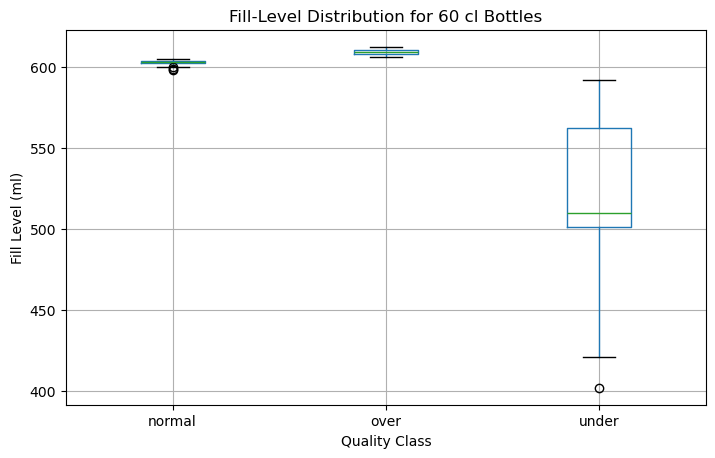

In [8]:
# Visual sanity check (boxplot)
import matplotlib.pyplot as plt

df_60cl.boxplot(column="fill_level", by="label", figsize=(8, 5))
plt.title("Fill-Level Distribution for 60 cl Bottles")
plt.suptitle("")
plt.xlabel("Quality Class")
plt.ylabel("Fill Level (ml)")
plt.show()


In [9]:
# Class balance assessment (confirmation)
df_60cl["label"].value_counts()

label
normal    33
under     21
over      20
Name: count, dtype: int64

In [10]:
# Decide augmentation target (VERY IMPORTANT)
# Controlled augmentation
np.random.seed(42)

TARGET_SAMPLES = 100

augmented_rows = []

for label in ["under", "normal", "over"]:
    df_class = df_60cl[df_60cl["label"] == label]
    current_n = len(df_class)
    
    # Keep original data
    augmented_rows.append(df_class)
    
    # How many new samples needed
    samples_needed = TARGET_SAMPLES - current_n
    
    if samples_needed > 0:
        # Determine fill-level range per class
        min_fill = df_class["fill_level"].min()
        max_fill = df_class["fill_level"].max()
        
        # Generate synthetic samples
        synth_fill = np.random.uniform(min_fill, max_fill, samples_needed)
        synth_temp = np.random.normal(
            df_class["temperature"].mean(),
            df_class["temperature"].std(),
            samples_needed
        )
        synth_speed = np.random.normal(
            df_class["production_speed"].mean(),
            df_class["production_speed"].std(),
            samples_needed
        )
        
        synth_df = pd.DataFrame({
            "fill_level": synth_fill,
            "temperature": synth_temp,
            "production_speed": synth_speed,
            "label": label
        })
        
        augmented_rows.append(synth_df)

# Combine all
df_60cl_balanced = pd.concat(augmented_rows, ignore_index=True)


In [11]:
# Verify balance (CRITICAL CHECK)
df_60cl_balanced["label"].value_counts()

label
under     100
normal    100
over      100
Name: count, dtype: int64

In [12]:
# Final quick sanity check
df_60cl_balanced.describe()



,fill_level,temperature,production_speed
count,300.000000,300.000000,300.000000
mean,569.307130,11.694951,15.420000
std,61.145649,4.450660,4.275727
min,402.200000,0.326914,4.677124
25%,548.803021,8.373528,12.895460
50%,602.008939,11.214951,16.295157
75%,607.600067,14.100000,18.194598
max,612.300000,29.696735,25.458756


In [13]:
df_60cl_balanced.groupby("label")["fill_level"].agg(
    min="min", max="max", mean="mean"
)

,min,max,mean
label,,,
normal,597.8,604.8,601.533364
over,606.1,612.3,609.202033
under,402.2,592.1,497.185994


In [14]:
# saving a CSV
from pathlib import Path

# Define output path
out_file_60cl = Path("60cl_clean_augmented.csv")

# Save balanced dataset
df_60cl_balanced.to_csv(out_file_60cl, index=False)

print("Saved cleaned + augmented CSV to:", out_file_60cl.resolve())


Saved cleaned + augmented CSV to: /home/abraham/ml_project2/60cl_clean_augmented.csv


In [15]:
pd.read_csv("60cl_clean_augmented.csv").head()


,fill_level,temperature,production_speed,label
0,540.3,12.3,17.420,under
1,532.8,11.2,17.812,under
2,591.1,11.4,15.200,under
3,591.8,11.2,19.000,under
4,509.1,16.4,8.290,under


In [16]:
# Load the balanced dataset
df_60cl_balanced = pd.read_csv("60cl_clean_augmented.csv")


In [17]:
# Separate features and labels
X = df_60cl_balanced[["fill_level", "temperature", "production_speed"]]
y = df_60cl_balanced["label"]


In [18]:
# Perform train–test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [19]:
# Verify the split
print("Training set class distribution:\n", y_train.value_counts())
print("\nTest set class distribution:\n", y_test.value_counts())


Training set class distribution:
 label
normal    80
over      80
under     80
Name: count, dtype: int64

Test set class distribution:
 label
normal    20
under     20
over      20
Name: count, dtype: int64


In [20]:
# Import Random Forest and metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [21]:
# Initialize the Random Forest model
rf_60cl = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [22]:
# Train the model
rf_60cl.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
# Make predictions on test data
y_pred = rf_60cl.predict(X_test)

In [24]:
# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy (60 cl):", accuracy)


Random Forest Accuracy (60 cl): 1.0


In [25]:
# Import evaluation tools
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["under", "normal", "over"])


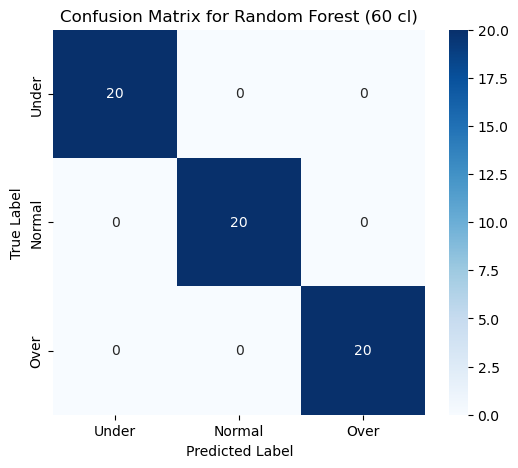

In [27]:
# Plot confusion matrix (baseline – no noise)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Under", "Normal", "Over"],
    yticklabels=["Under", "Normal", "Over"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Random Forest (60 cl)")
plt.show()


In [28]:
# Print classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        20
        over       1.00      1.00      1.00        20
       under       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [29]:
# Create noisy test data (σ = 2 ml)
# Copy test features
X_test_noisy = X_test.copy()

# Add strong Gaussian noise to fill level
np.random.seed(42)
X_test_noisy["fill_level"] = (
    X_test_noisy["fill_level"]
    + np.random.normal(0, 2, size=len(X_test_noisy))
)


In [30]:
# Predict using the trained Random Forest
y_pred_noisy = rf_60cl.predict(X_test_noisy)# Predict using the trained Random Forest
y_pred_noisy = rf_60cl.predict(X_test_noisy)


In [31]:
# Compute accuracy under noise
from sklearn.metrics import accuracy_score

accuracy_noisy = accuracy_score(y_test, y_pred_noisy)
print("Accuracy under strong noise stress (σ = 2 ml):", accuracy_noisy)


Accuracy under strong noise stress (σ = 2 ml): 0.9666666666666667


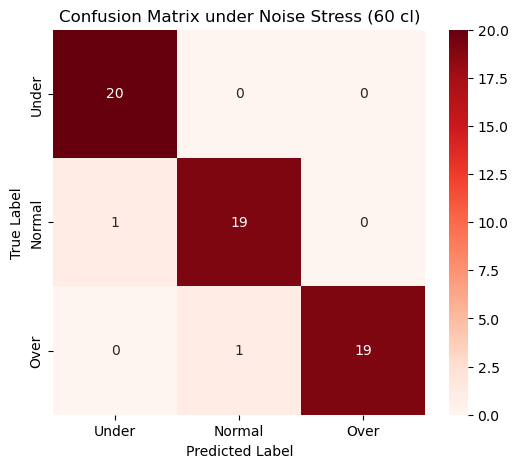

In [32]:
# Confusion matrix (noise stress)
cm_noisy = confusion_matrix(y_test, y_pred_noisy, labels=["under", "normal", "over"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_noisy,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Under", "Normal", "Over"],
    yticklabels=["Under", "Normal", "Over"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix under Noise Stress (60 cl)")
plt.show()


In [33]:
# Classification report (noise stress)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_noisy))


              precision    recall  f1-score   support

      normal       0.95      0.95      0.95        20
        over       1.00      0.95      0.97        20
       under       0.95      1.00      0.98        20

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



In [34]:
# Create noisy test data (σ = 5 ml)
# Copy test features
X_test_noisy = X_test.copy()

# Add strong Gaussian noise to fill level
np.random.seed(42)
X_test_noisy["fill_level"] = (
    X_test_noisy["fill_level"]
    + np.random.normal(0, 5, size=len(X_test_noisy))
)

In [35]:
# Predict using the trained Random Forest
y_pred_noisy = rf_60cl.predict(X_test_noisy)# Predict using the trained Random Forest
y_pred_noisy = rf_60cl.predict(X_test_noisy)

In [36]:
# Compute accuracy under noise
from sklearn.metrics import accuracy_score

accuracy_noisy = accuracy_score(y_test, y_pred_noisy)
print("Accuracy under strong noise stress (σ = 5 ml):", accuracy_noisy)

Accuracy under strong noise stress (σ = 5 ml): 0.85


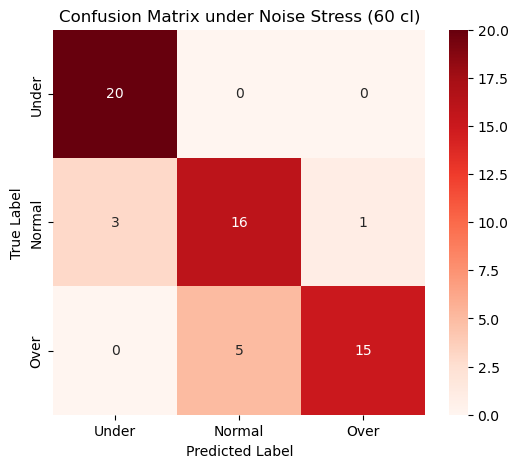

In [37]:
# Confusion matrix (noise stress)
cm_noisy = confusion_matrix(y_test, y_pred_noisy, labels=["under", "normal", "over"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_noisy,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Under", "Normal", "Over"],
    yticklabels=["Under", "Normal", "Over"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix under Noise Stress (60 cl)")
plt.show()


In [38]:
# Feature Importance
# Extract feature importance
import pandas as pd

feature_importance_60cl = pd.Series(
    rf_60cl.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance_60cl


fill_level          0.677725
production_speed    0.186806
temperature         0.135470
dtype: float64

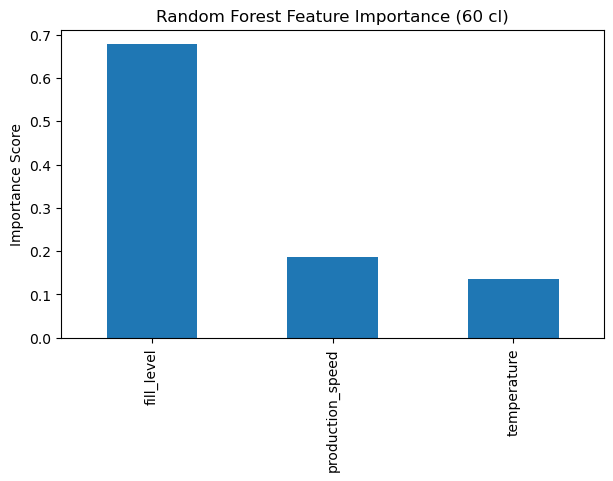

In [39]:
# Plot feature importance (figure for Chapter 4)
feature_importance_60cl.plot(
    kind="bar",
    figsize=(7, 4),
    title="Random Forest Feature Importance (60 cl)"
)
plt.ylabel("Importance Score")
plt.show()


In [40]:
# Import XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report


In [41]:
# Encode labels (add ONE new cell)
from sklearn.preprocessing import LabelEncoder

# Create label encoder
le = LabelEncoder()

# Encode labels
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Optional: see mapping (VERY useful for dissertation)
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
label_mapping


{'normal': np.int64(0), 'over': np.int64(1), 'under': np.int64(2)}

In [42]:
xgb_60cl = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    random_state=42
)


In [43]:
# Train XGBoost using encoded labels
xgb_60cl.fit(X_train, y_train_enc)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [44]:
# Predict and decode back to original labels
y_pred_xgb_enc = xgb_60cl.predict(X_test)

# Convert predictions back to original labels
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)


In [45]:
# Evaluate (same as before)
from sklearn.metrics import accuracy_score, classification_report

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy (60 cl):", xgb_accuracy)

print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy (60 cl): 1.0
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        20
        over       1.00      1.00      1.00        20
       under       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [46]:
print(classification_report(y_test, y_pred_noisy))


              precision    recall  f1-score   support

      normal       0.76      0.80      0.78        20
        over       0.94      0.75      0.83        20
       under       0.87      1.00      0.93        20

    accuracy                           0.85        60
   macro avg       0.86      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60



In [47]:
# Prepare full dataset
X_full = df_60cl_balanced[["fill_level", "temperature", "production_speed"]]
y_full = df_60cl_balanced["label"]


In [48]:
# Initialize final Random Forest model

rf_60cl_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [49]:
# Train Random Forest on full dataset
rf_60cl_final.fit(X_full, y_full)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [50]:
# Initialize final XGBoost model
from sklearn.preprocessing import LabelEncoder

le_final = LabelEncoder()
y_full_enc = le_final.fit_transform(y_full)


In [51]:
xgb_60cl_final = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    random_state=42
)


In [52]:
# Train XGBoost on full dataset
xgb_60cl_final.fit(X_full, y_full_enc)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [53]:
# save models
import joblib

joblib.dump(rf_60cl_final, "rf_60cl_final.pkl")
joblib.dump(xgb_60cl_final, "xgb_60cl_final.pkl")
joblib.dump(le_final, "label_encoder_60cl.pkl")


['label_encoder_60cl.pkl']

In [54]:
# Learning Curve for Random Forest
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

In [55]:
# Define model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Generate learning curve
train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_full,
    y_full,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

# Compute mean scores
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)


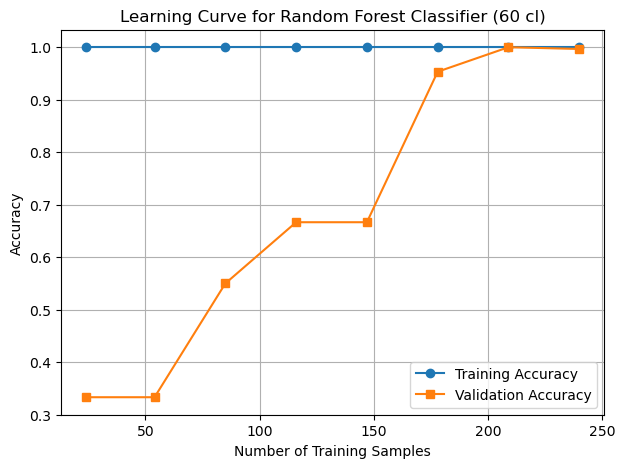

In [56]:
# Plot learning curve
plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker='s', label="Validation Accuracy")
plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve for Random Forest Classifier (60 cl)")
plt.legend()
plt.grid(True)
plt.show()
